In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful 🚀")

Setup successful 🚀


In [1]:
import pandas as pd

print(pd.__version__)

2.3.3


In [1]:
print("kernel alive")

kernel alive


In [6]:
file_path = "../data/Online_Retail.xlsx"

In [7]:
file_path = "../data/Online_Retail.xlsx"

df = pd.read_excel(file_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df = df.dropna(subset=['CustomerID'])

In [10]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [13]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

In [14]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]


In [15]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [16]:
df.shape

(397884, 8)

In [17]:
import pandas as pd

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [18]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'count',
    'Quantity': lambda x: (x * df.loc[x.index, 'UnitPrice']).sum()
})

In [19]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,182,4310.00
12348,75,31,1797.24
12349,19,73,1757.55
12350,310,17,334.40


In [20]:
rfm['Frequency'] = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [21]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [22]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [23]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [24]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,4,114
12347,2,7,4310.00,4,4,4,444
12348,75,4,1797.24,2,3,4,234
12349,19,1,1757.55,3,1,4,314
12350,310,1,334.40,1,1,2,112


In [25]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'Champions'
    elif row['R_Score'] == 4 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'Potential Loyalists'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [26]:
rfm['Segment'].value_counts()

Segment
Lost                   2136
Potential Loyalists     665
At Risk                 646
Champions               490
Loyal Customers         401
Name: count, dtype: int64

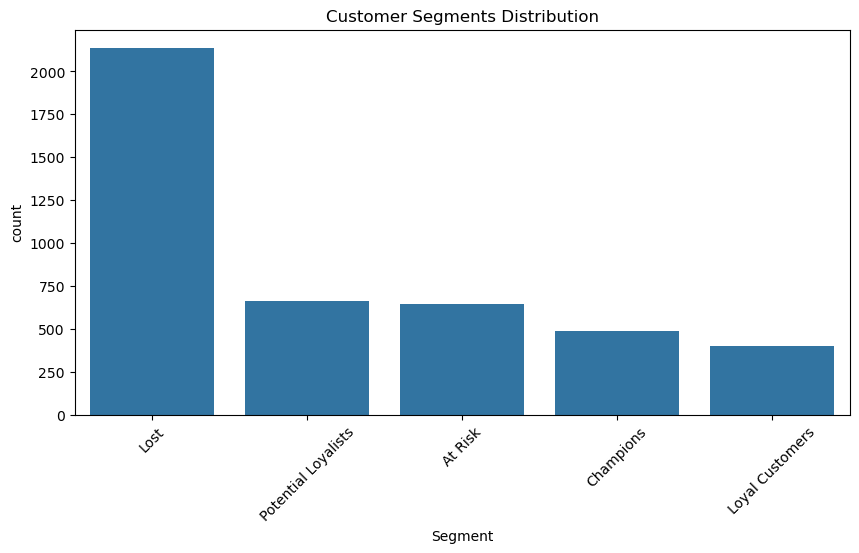

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Customer Segments Distribution")
plt.show()

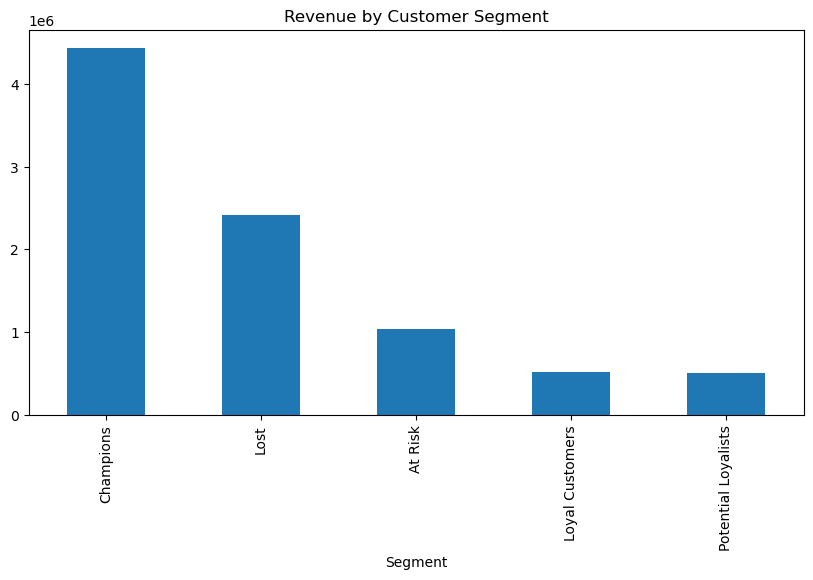

In [28]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

segment_revenue.plot(kind='bar', figsize=(10,5), title='Revenue by Customer Segment')
plt.show()

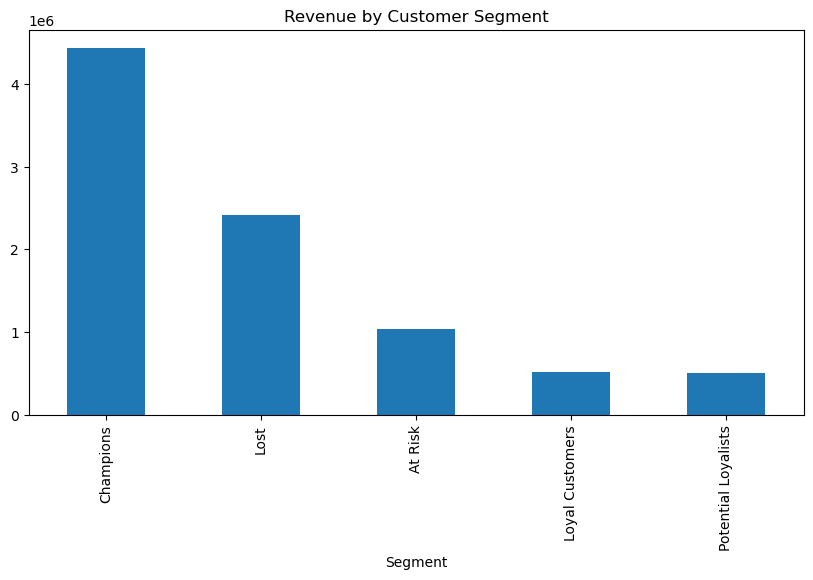

In [29]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

segment_revenue.plot(kind='bar', figsize=(10,5), title='Revenue by Customer Segment')
plt.show()

In [30]:
rfm['Segment'].value_counts()

Segment
Lost                   2136
Potential Loyalists     665
At Risk                 646
Champions               490
Loyal Customers         401
Name: count, dtype: int64

In [31]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Champions              4434743.730
Lost                   2416963.043
At Risk                1040932.691
Loyal Customers         516815.220
Potential Loyalists     501953.220
Name: Monetary, dtype: float64

In [32]:
total_revenue = rfm['Monetary'].sum()

segment_share = (rfm.groupby('Segment')['Monetary'].sum() / total_revenue) * 100
segment_share.sort_values(ascending=False)

Segment
Champions              49.764793
Lost                   27.122123
At Risk                11.680901
Loyal Customers         5.799479
Potential Loyalists     5.632704
Name: Monetary, dtype: float64

In [33]:
top_15_percent_cutoff = int(len(rfm) * 0.15)

top_customers = rfm.sort_values('Monetary', ascending=False).head(top_15_percent_cutoff)

top_share = (top_customers['Monetary'].sum() / rfm['Monetary'].sum()) * 100

top_share

np.float64(68.89024727781107)

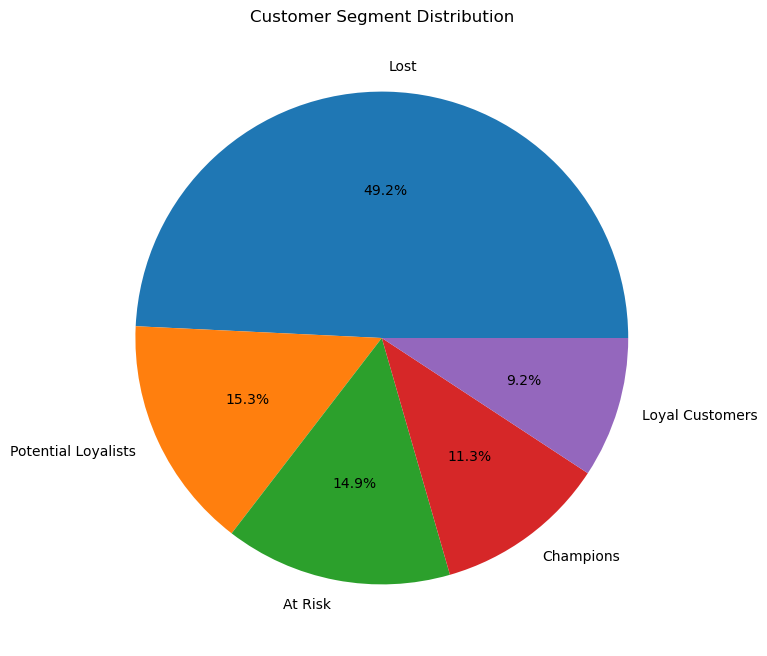

In [34]:
plt.figure(figsize=(8,8))
rfm['Segment'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.show()

In [35]:
rfm['CLV_Score'] = rfm['Frequency'] * rfm['Monetary']
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,CLV_Score
CustomerID,,,,,,,,,
12346,326,1,77183.60,1,1,4,114,Lost,77183.60
12347,2,7,4310.00,4,4,4,444,Champions,30170.00
12348,75,4,1797.24,2,3,4,234,At Risk,7188.96
12349,19,1,1757.55,3,1,4,314,Potential Loyalists,1757.55
12350,310,1,334.40,1,1,2,112,Lost,334.40


In [36]:
rfm.sort_values('CLV_Score', ascending=False).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,CLV_Score
CustomerID,,,,,,,,,
14911,1,201,143825.06,4,4,4,444,Champions,28908837.06
14646,2,73,280206.02,4,4,4,444,Champions,20455039.46
18102,1,60,259657.30,4,4,4,444,Champions,15579438.00
17450,8,46,194550.79,4,4,4,444,Champions,8949336.34
12748,1,209,33719.73,4,4,4,444,Champions,7047423.57
14156,10,55,117379.63,4,4,4,444,Champions,6455879.65
13089,3,97,58825.83,4,4,4,444,Champions,5706105.51
15311,1,91,60767.90,4,4,4,444,Champions,5529878.90
16029,39,63,81024.84,3,4,4,344,Lost,5104564.92


In [37]:
def segment_v2(row):
    if row['R_Score'] == 4 and row['F_Score'] == 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] == 4 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost'
    else:
        return 'Potential Customers'

rfm['Segment_V2'] = rfm.apply(segment_v2, axis=1)

In [38]:
rfm['Segment_V2'].value_counts()

Segment_V2
Lost                   1504
Loyal Customers         914
At Risk                 646
Champions               609
Potential Customers     431
New Customers           234
Name: count, dtype: int64

In [39]:
segment_actions = {
    'Champions': 'Reward + VIP offers',
    'Loyal Customers': 'Upsell + loyalty programs',
    'New Customers': 'Onboarding + engagement campaigns',
    'Potential Customers': 'Nurture marketing',
    'At Risk': 'Win-back campaigns',
    'Lost': 'Ignore or low-cost reactivation'
}

rfm['Business_Action'] = rfm['Segment_V2'].map(segment_actions)

rfm[['Segment_V2', 'Business_Action']].head()

,Segment_V2,Business_Action
CustomerID,,
12346,Lost,Ignore or low-cost reactivation
12347,Champions,Reward + VIP offers
12348,At Risk,Win-back campaigns
12349,Potential Customers,Nurture marketing
12350,Lost,Ignore or low-cost reactivation
